In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

run on range a1 (slope):  
--run on range a2 (intercept):  
  1. check that all points groupA are in the correct side if one point is invalid (wrong side) then continue ... bad plane
  2. check that all points groupB are in the correct side if one point is invalid (wrong side) then continue ... bad plane    
3. find the closest point from group
  4.  find the closest point from group
  5.  find minimum of closest groupA and closest groupB 5. save the a1, a2 (slope intercept) and the closest poin  t

in all good-results find the one with the biggest close point

Searching for best separating line...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


3.787878787878787
-10.0
1.005548803070833


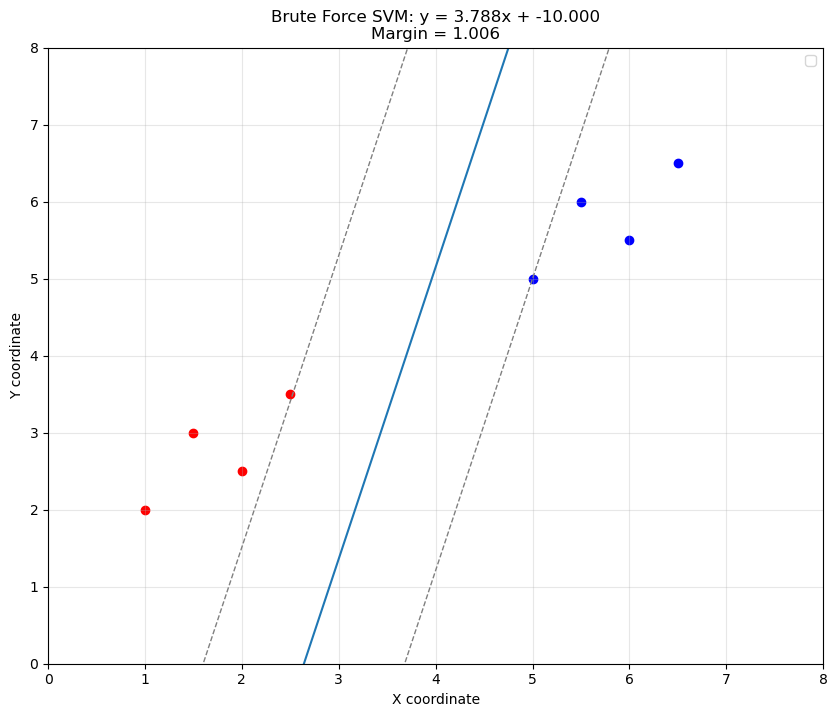

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create sample data: two groups of (x, y) points
group_a = np.array([[1, 2], [1.5, 3], [2, 2.5], [2.5, 3.5]])
group_b = np.array([[5, 5], [5.5, 6], [6, 5.5], [6.5, 6.5]])

# Combine into training data
points = np.vstack([group_a, group_b])
labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 0 for group A, 1 for group B

# find the best svm plane

def get_signed_distance(point, a1, a2, c):
        x = point[0]
        y = point[1]
        numerator = a1 * x + a2 * y + c
        denominator = np.sqrt(a1**2 + a2**2)
        vec_dist = numerator / denominator
        return vec_dist

def get_abs_distance(point, a1, a2, c):
    return abs(distance(point, a1, a2, c))

slopes = np.linspace(-5, 5, 100)
intercepts = np.linspace(-10, 20, 100)

print("Searching for best separating line...")

largest_distance_from_min = -1  # the largest distance from the closest point
best_slope = None
best_intercept = None
for slope in slopes:
    for intercept in intercepts:
        # a1*X + a2*Y + c = 0
        
        # y = aX + b
        # 0 = aX + b -1*y 
        # 0 = aX -1*y + b
        # 0 = aX -1*y + c
        # a1 = slope
        # a2 = -1
        # c = intercept
        
        # step 1 check if all points are in he correct side
        # signed_distance
        # if label == 0 --> get_signed_distance (negative)
        # if label == 1 --> get_signed_distance (positive)
        # if 1 point does not match --> continue
        # save the line

        valid = True
        distances = []
        for point in group_a:
            dist = get_signed_distance(point, slope, -1, intercept)
            # should be negative, if positive -- the line is invalid
            if dist >= 0:
                valid = False
            else:
                distances.append(abs(dist))

        for point in group_b:
            dist = get_signed_distance(point, slope, -1, intercept)
            # should be positive, if negative -- the line is invalid
            if dist <= 0:
                valid = False
            else:
                distances.append(abs(dist))

        if not valid:
            continue

        # step 2 - find the closest point to this surface
        # place all disatnces in a list and choose the minimum
        closest_point_distance = min(distances)  # closest point to the surface
        if closest_point_distance > largest_distance_from_min:
            largest_distance_from_min = closest_point_distance
            best_slope = slope
            best_intercept = intercept

print(best_slope)
print(best_intercept)
print(largest_distance_from_min)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend()
ax.set_title(f'Brute Force SVM: y = {best_slope:.3f}x + {best_intercept:.3f}\nMargin = {largest_distance_from_min:.3f}')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)

line_x = np.linspace(0, 10, 10)
line_y = best_slope * line_x + best_intercept
ax.plot(line_x, line_y)


ax.scatter(group_a[: , 0], group_a[: , 1], color='red')
ax.scatter(group_b[: , 0], group_b[: , 1], color='blue')

offset = largest_distance_from_min * np.sqrt(best_slope**2 + (-1)**2)

# Upper margin line
y_upper = best_slope * line_x + (best_intercept + offset)
ax.plot(line_x, y_upper, 'gray', linewidth=1, linestyle='--', label='Margin')

# Lower margin line
y_lower = best_slope * line_x + (best_intercept - offset)
ax.plot(line_x, y_lower, 'gray', linewidth=1, linestyle='--')

plt.show()


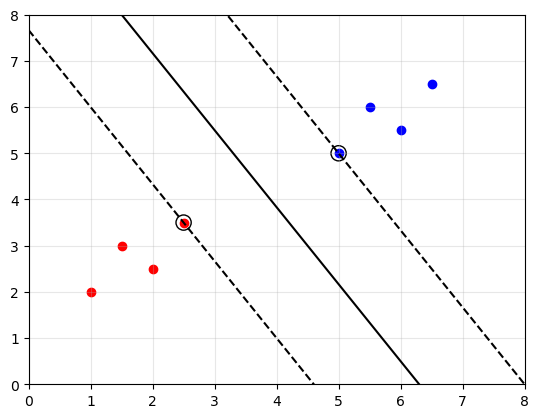

[0.58823529 0.35294118]
-3.705882352941176


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Create sample data: two groups of (x, y) points
group_a = np.array([[1, 2], [1.5, 3], [2, 2.5], [2.5, 3.5]])
group_b = np.array([[5, 5], [5.5, 6], [6, 5.5], [6.5, 6.5]])

# Combine into training data
points = np.vstack([group_a, group_b])
labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 0 for group A, 1 for group B

# find the best svm plane
clf = SVC(kernel="linear")
clf.fit(points, labels)

# Extract w and b
# w0X0 + w1X1 + w2X2 .... + b = 0

# w0X0 + w1X1 + b = 0
# Ax   + By   + c = 0
# Y = aX + b

# Ax + By + c = 0
# -By = Ax + c  /:-B
# y = -(A/B) * x + c/-B
# y = slope * x + intercept

# w = [[A, B]]
# y = ax + b

# w1*x + w2*y + b = 0
# w2*y = -w1*x - b 
# y = -(w1/w2)*x - b/w2 


w = clf.coef_[0]
b = clf.intercept_[0]
best_slope = -(w[0]/w[1])
best_intercept = (-b / w[1])

# Decision boundary
line_x = np.linspace(0, 8, 100)
line_y = best_slope * line_x + best_intercept

# Margin lines (always ±1 with sklearn)
# w1*x + w2*y + b = 1
# w2*y = -w1*x - b + 1
# y = -(w1/w2)*x - b/w2 + (1/w2)
# y = -(w1/w2)*x - b/w2 
y_up = line_y + 1 / w[1]
y_down = line_y - 1 / w[1]

# --- Plot ---
plt.scatter(group_a[:, 0], group_a[:, 1], color="red")
plt.scatter(group_b[:, 0], group_b[:, 1], color="blue")
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            edgecolors="black", facecolors="none", s=120)

plt.plot(line_x, line_y, "k")       # decision boundary
plt.plot(line_x, y_up, "k--")       # margin
plt.plot(line_x, y_down, "k--")     # margin

plt.xlim(0, 8)
plt.ylim(0, 8)
plt.grid(True, alpha=0.3)
plt.show()
# Ax + By + c = 0
# Ax + c = By
# A/B * x + c/B
# 0.58823529 * X + 0.35 * Y - 3.7 = 0
# 
print(w) 
print(b)

In [43]:
# evaluation
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = clf.predict(points)
cm = confusion_matrix(labels, y_pred)
print("prediction:", y_pred)
print("true:      ", y_pred)
print()
print("Confusion matrix:\n", cm)

print("Accuracy:", accuracy_score(labels, y_pred))

prediction: [0 0 0 0 1 1 1 1]
true:       [0 0 0 0 1 1 1 1]

Confusion matrix:
 [[4 0]
 [0 4]]
Accuracy: 1.0
